# IFN680 Project 7: Improving DDPM - DDPM_CosineSchedule

**Group 4** - Karan Rooprai (n12498122), Nhu Hieu Nguyen (n12194778)

This notebook is **Task 1**. It trains the conditional denoising diffusion probabilistic model (DDPM) of Tutorial 9.3 on `mnist_custom.pt` twice: once with the tutorial's `linear_beta_schedule`, and once with a `cosine_beta_schedule` implemented here. Everything else is shared, so the noise schedule is the only difference between the two models. `main_report.ipynb` compares them.

The hypothesis under test:

> *A cosine schedule allows a denoising diffusion probabilistic model to generate high-quality samples using fewer time steps than a linear schedule.*

The notebook follows the tutorial's order and keeps its code wherever it can. `extract`, `linear_beta_schedule`, `ConvBlock` and `UNet_cond` are the tutorial's, unchanged, and so are the optimiser, the learning rate, the batch size, the loss and the 1000 diffusion steps. What differs:

| | Tutorial 9.3 | This notebook | Why |
|---|---|---|---|
| Data | torchvision's MNIST, 28 x 28 | `mnist_custom.pt`, 20 x 20, dark digits on white | the brief's dataset; the U-Net needs no change for it (section 4) |
| Noise schedule | linear | linear and cosine, one model each | the hypothesis compares them (section 3) |
| Schedule arrays | globals `betas`, `alphas`, `alpha_bars` | one dictionary per schedule, passed to `q_sample` and the sampler | two schedules exist side by side |
| Training runs | one | three per schedule, seeds 0, 1 and 2 | a difference must survive retraining (section 5.3) |
| Epochs | 100 in the exercise, 150 in the solution | 150 | the solution's conditional model |
| Progress display | a tqdm bar per epoch | a printed line every 10 epochs | tqdm writes to the error stream |
| Sampler | all 1000 steps | the same update able to skip steps, in its x0 form with the clean-image estimate clipped, and DDIM | the hypothesis is about sampling in fewer steps (section 6) |

It writes `ddpm_linear.pth` and `ddpm_cosine.pth` (the weights), `DDPM_history.json` (every training curve and setting) and `mnist_custom_test.pt` (the test split).

**Sections:** 1 Setup, 2 The data, 3 The forward diffusion process, 4 The backward process, 5 Training, 6 Sampling, 7 Generated digits.

## 1 Setup

The libraries, the device and the seed. The printed versions make the executed notebook its own
record of where it ran. The palette cell below it keeps every figure in the same colours.

In [1]:
# The Week 9 tutorial's stack. json carries the training record to main_report.ipynb, and
# utils.make_grid lays out digit grids the way the tutorial's figures do.
import json
import os
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import DataLoader, TensorDataset
from torchvision import utils

# The brief asks for the IFN680 GPU environment. The same code runs on a CPU when no GPU is
# visible, so the notebook runs anywhere and every tensor is placed with .to(device).
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"device      : {device}")
print(f"python      : {platform.python_version()}")
print(f"torch       : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"numpy       : {np.__version__}")

# One seed for everything that is not given its own: initial weights and random draws.
SEED = 0
np.random.seed(SEED)
_ = torch.manual_seed(SEED)

device      : cuda:0
python      : 3.12.14
torch       : 2.13.0+cu126
torchvision : 0.28.0+cu126
numpy       : 2.5.3


In [2]:
# One palette for every figure in the project, so the figures read as a set.
INK, ACCENT, WARM = "#1f2933", "#2f6f9f", "#c1553b"
MUTED, PALE, GREEN = "#7b8794", "#e8ecf1", "#3f7d58"
plt.rcParams.update({"font.size": 8, "axes.titlesize": 8, "axes.edgecolor": MUTED,
                     "axes.spines.top": False, "axes.spines.right": False})

## 2 The data

`mnist_custom.pt` holds four tensors: 60,000 training images with their labels, and 10,000 test
images with theirs. The cell below loads it. Because `main_report.ipynb` needs the test split and
nothing else, the cell also writes that split to its own file, `mnist_custom_test.pt`, so the
archive does not have to carry the whole 112 MB dataset.

In [3]:
# mnist_custom.pt is the dataset supplied with the brief: MNIST resized to 20 x 20 and
# inverted. weights_only=True loads the tensors and refuses to run any code stored in the file.
data = torch.load("mnist_custom.pt", weights_only=True)
train_images, train_labels = data["train_images"], data["train_labels"]

# main_report.ipynb needs the test split and nothing else, so it is written to its own file
# here. No training notebook scores it or makes a prediction on it.
if not os.path.exists("mnist_custom_test.pt"):
    test_split = {key: data[key] for key in ("test_images", "test_labels")}
    torch.save(test_split, "mnist_custom_test.pt")
print(f"loaded mnist_custom.pt: {', '.join(data.keys())}")

loaded mnist_custom.pt: train_images, train_labels, test_images, test_labels


### 2.1 What the file holds

The brief describes the file only as a custom MNIST, so its properties are measured before
anything is trained on it. The images are **20 x 20**, not the tutorial's 28 x 28, and the
background is **white** (pixel value 1.0) with dark strokes, the reverse of the tutorial's MNIST.
Neither needs a change to the diffusion model: it learns to remove noise from whatever images it
is given, and the U-Net's two halvings of the image size work at 20 x 20 (section 4).

In [4]:
# What the file actually holds, measured before anything is trained on it.
border = torch.cat([train_images[..., 0, :], train_images[..., -1, :],
                    train_images[..., :, 0], train_images[..., :, -1]], dim=-1)
print(f"train_images : {tuple(train_images.shape)}, {train_images.dtype}")
print(f"train_labels : {tuple(train_labels.shape)}, {train_labels.dtype}")
print(f"pixel range  : {train_images.min():.3f} to {train_images.max():.3f}")
print(f"class counts : {torch.bincount(train_labels, minlength=10).tolist()}")
# The background is white (1.0) and the strokes dark: the reverse of the tutorial's MNIST.
print(f"pixels exactly 1.0 : {(train_images == 1).float().mean():.3f}")
print(f"mean border pixel  : {border.mean():.4f}")

train_images : (60000, 1, 20, 20), torch.float32
train_labels : (60000,), torch.int64
pixel range  : 0.000 to 1.000
class counts : [5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]
pixels exactly 1.0 : 0.701
mean border pixel  : 0.9993


### 2.2 Scaling and batches

The tutorial's transform `x*2-1` maps every pixel from [0, 1] to [-1, 1]. The forward process of
section 3 ends in pure noise with mean 0 and variance 1, so the clean images are put on a
comparable scale, centred on 0. The tutorial trains in shuffled batches of 128; each training run
in section 5 builds its own `DataLoader` over this dataset.

| Call | What you give it | What you get back |
|---|---|---|
| `TensorDataset(images, labels)` | tensors with the same first dimension | a dataset whose item i is (images[i], labels[i]) |

In [5]:
# The tutorial's transform, x*2-1, takes every pixel from [0, 1] to [-1, 1]. Batches of 128 as
# in the tutorial; each training run builds its own seeded DataLoader over this dataset.
N_TRAIN = 60000
train_dataset = TensorDataset(train_images[:N_TRAIN] * 2 - 1, train_labels[:N_TRAIN])
bs_train = 128
image_size = 20
n_class = 10
scaled = train_dataset.tensors[0]
print(f"training images: {len(train_dataset):,}, pixels from {scaled.min():.0f} to "
      f"{scaled.max():.0f}, batches of {bs_train}")

training images: 60,000, pixels from -1 to 1, batches of 128


## 3 The forward diffusion process

A diffusion model learns to generate images by learning to undo noise. The **forward process**
destroys an image in T = 1000 small steps. At step t it keeps most of the image and adds a little
Gaussian noise:

$$x_t = \sqrt{1 - \beta_t}\, x_{t-1} + \sqrt{\beta_t}\, \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)$$

The sequence $\beta_1, \dots, \beta_T$ is the **noise schedule**, the subject of this project.
Writing $\alpha_t = 1 - \beta_t$ and $\bar\alpha_t = \alpha_1 \alpha_2 \cdots \alpha_t$, the
tutorial shows that the steps combine into one jump from the clean image:

$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1 - \bar\alpha_t}\, \epsilon$$

So $\bar\alpha_t$ is the share of the clean image's signal left at step t: 1 at the start and
close to 0 at the end, where $x_T$ is pure noise. **A schedule decides how fast
$\bar\alpha_t$ falls**, and so how many of the 1000 steps are spent at each noise level.

### 3.1 The linear schedule

The cell below is the tutorial's, unchanged. `extract` picks each image's value out of a
schedule array at that image's own step t, and `linear_beta_schedule` spaces the betas evenly from
0.0001 to 0.02.

| Call | What you give it | What you get back |
|---|---|---|
| `a.gather(-1, t)` | a schedule array and one step index per image | the array's value at each image's step |
| `torch.linspace(start, end, n)` | two ends and a count | n evenly spaced values from start to end |

In [6]:
# Supplied by Tutorial 9.3 and reproduced unchanged. extract() picks each image's schedule
# value at its own step t, and linear_beta_schedule() is the baseline schedule under test.
def extract(a, t, x_shape):
    """
    Extracts coefficients at specified timesteps, then reshapes to [batch_size, 1, 1, 1] for broadcasting purposes 
    (piecewise multiplication with the noise image)
    a: Tensor of shape (num_timesteps) (e.g. alpha_bar)
    t: Tensor of shape (batch_size) with timestep indices
    """    
    batch_size = t.shape[0]
    out = a.gather(-1, t).reshape(batch_size, *((1,) * (len(x_shape) - 1)))
    return out


timesteps = 1000


def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start,beta_end, timesteps)

### 3.2 The cosine schedule

Nichol and Dhariwal (2021) observed that with the linear schedule the end of the forward process
is almost pure noise, so those steps contribute little. Their **cosine schedule** defines
$\bar\alpha_t$ directly, falling slowly at the start and the end and fastest in the middle:

$$\bar\alpha_t = \frac{f(t)}{f(0)}, \qquad f(t) = \cos^2\left(\frac{t/T + s}{1 + s} \cdot \frac{\pi}{2}\right), \qquad \beta_t = 1 - \frac{\bar\alpha_t}{\bar\alpha_{t-1}}$$

The offset s = 0.008 keeps the first betas from being vanishingly small: they chose it so that
$\sqrt{\beta_0}$ is slightly smaller than one pixel step of the [-1, 1] range, 1/127.5. Each beta
is clipped at 0.999, because $\bar\alpha_T$ is 0 and the last beta would otherwise be exactly 1.

`cosine_beta_schedule` below is written from that formula. `make_schedule` then turns either
schedule's betas into the three arrays the tutorial keeps as globals, one dictionary per schedule,
and the printed lines show where each starts and ends.

| Call | What you give it | What you get back |
|---|---|---|
| `torch.cos(x)` | a tensor | the cosine of every value |
| `torch.clip(x, max=m)` | a tensor and a ceiling | the tensor with every value above m set to m |
| `torch.cumprod(a, dim=0)` | a 1-D tensor | the running product: a[0], a[0]a[1], a[0]a[1]a[2], ... |

In [7]:
# The schedule under test, written from Nichol and Dhariwal (2021), eq. 17: alpha_bar follows
# a squared cosine of t/T, offset by s = 0.008, and each beta is recovered as
# 1 - alpha_bar(t) / alpha_bar(t-1). Double precision, because near t = T this divides two very
# small numbers; beta is clipped at 0.999 because alpha_bar(T) is 0, which would make it 1.
def cosine_beta_schedule(timesteps, s=0.008):
    steps = torch.linspace(0, 1, timesteps + 1, dtype=torch.float64)
    f = torch.cos((steps + s) / (1 + s) * torch.pi / 2) ** 2
    alpha_bar = f / f[0]
    betas = 1 - alpha_bar[1:] / alpha_bar[:-1]
    return torch.clip(betas, max=0.999).float()

In [8]:
# One dictionary per schedule holds the three arrays the tutorial keeps as globals, so both
# schedules can be used side by side. alpha_bar is the running product of the alphas.
def make_schedule(betas):
    betas = betas.to(device)
    alphas = 1.0 - betas
    return {"betas": betas, "alphas": alphas, "alpha_bars": torch.cumprod(alphas, dim=0)}


SCHEDULE_FUNCTIONS = {"linear": linear_beta_schedule, "cosine": cosine_beta_schedule}
schedules = {name: make_schedule(build(timesteps)) for name, build in SCHEDULE_FUNCTIONS.items()}
for name, schedule in schedules.items():
    betas, alpha_bars = schedule["betas"], schedule["alpha_bars"]
    print(f"{name:6s} | beta from {betas[0]:.6f} to {betas[-1]:.4f} | alpha_bar from "
          f"{alpha_bars[0]:.6f} down to {alpha_bars[-1]:.2e}")
    # alpha_bar must fall at every step, or the process would un-noise the image somewhere
    assert bool((alpha_bars[1:] < alpha_bars[:-1]).all())

linear | beta from 0.000100 to 0.0200 | alpha_bar from 0.999900 down to 4.04e-05
cosine | beta from 0.000041 to 0.9990 | alpha_bar from 0.999959 down to 2.43e-09


### 3.3 Jumping to step t

The tutorial's `q_sample` computes the one-jump formula above. The only change is that the
schedule is passed in, so the same function serves both models.

| Call | What you give it | What you get back |
|---|---|---|
| `torch.randn_like(x)` | a tensor | standard normal noise of the same shape, on the same device |

In [9]:
# The tutorial's q_sample with one change: the schedule is an argument instead of a global.
# It jumps straight from a clean image x0 to step t:
# x_t = sqrt(alpha_bar_t) * x0 + sqrt(1 - alpha_bar_t) * noise.
def q_sample(x0, t, schedule, noise=None):
    if noise is None:
        noise = torch.randn_like(x0).to(device)
    alpha_bars = schedule["alpha_bars"]
    sqrt_alpha_bar = torch.sqrt(extract(alpha_bars,t,x0.shape))
    sqrt_one_minus_alpha_bar = torch.sqrt(extract(1-alpha_bars,t,x0.shape))
    return sqrt_alpha_bar*x0 + noise*sqrt_one_minus_alpha_bar

### 3.4 What each schedule does to a digit

The tutorial's picture of the forward process at steps 25, 50, 100, 250, 500 and 999, drawn for
both schedules from the same four training digits and the same noise. The linear row fades to
noise sooner than the cosine row; section 3.5 puts numbers on it.

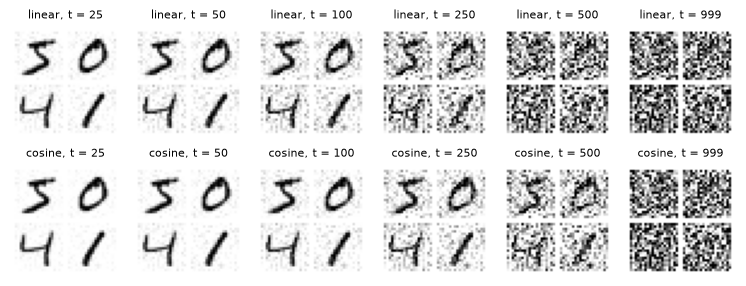

In [10]:
# The tutorial's picture of the forward process, drawn for both schedules from the same four
# training digits and the same noise, so every difference between the two rows is the schedule.
timesteps_investigated = [25, 50, 100, 250, 500, 999]
img = train_dataset.tensors[0][:4].to(device)
noise = torch.randn(img.shape, generator=torch.Generator().manual_seed(SEED)).to(device)
fig, axes = plt.subplots(2, len(timesteps_investigated), figsize=(7.5, 3.0))
for row, (name, schedule) in enumerate(schedules.items()):
    for col, step in enumerate(timesteps_investigated):
        t = torch.full((img.shape[0],), step, device=device, dtype=torch.long)
        noised = q_sample(img, t, schedule, noise).clamp(-1, 1)
        grid = utils.make_grid((noised + 1) / 2, nrow=2, pad_value=1)[0].cpu()
        axes[row, col].imshow(grid, cmap="gray", vmin=0, vmax=1)
        axes[row, col].set_title(f"{name}, t = {step}")
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

### 3.5 Where each schedule spends its steps

The left panel plots $\bar\alpha_t$; the right plots the same information as the **log
signal-to-noise ratio**, $\log(\bar\alpha_t / (1 - \bar\alpha_t))$, which spreads out the values
crowded near 0 and 1. The printed lines count the steps at which less than 1% of the signal is
left and the image is almost pure noise. A sampler walks through every one of those steps with
little left to do, which is the inefficiency the cosine schedule was designed to remove.

| Call | What you give it | What you get back |
|---|---|---|
| `tensor.double()` | a tensor | the same values in double precision |

linear | steps with alpha_bar below 0.01: 32.7% | alpha_bar at the last step: 4.04e-05
cosine | steps with alpha_bar below 0.01: 6.5% | alpha_bar at the last step: 2.43e-09


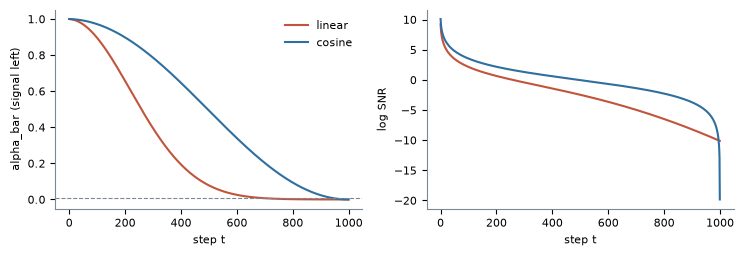

In [11]:
# Where each schedule spends its 1000 steps. alpha_bar is the share of the clean image's signal
# left at step t; below 0.01 the image is almost pure noise. log SNR carries the same
# information on a scale that does not bunch up near 0 and 1.
fig, (ax_bar, ax_snr) = plt.subplots(1, 2, figsize=(7.5, 2.6))
steps = np.arange(timesteps)
for (name, schedule), colour in zip(schedules.items(), (WARM, ACCENT)):
    alpha_bars = schedule["alpha_bars"].double().cpu().numpy()
    ax_bar.plot(steps, alpha_bars, color=colour, label=name)
    ax_snr.plot(steps, np.log(alpha_bars / (1 - alpha_bars)), color=colour, label=name)
    print(f"{name:6s} | steps with alpha_bar below 0.01: {(alpha_bars < 0.01).mean():.1%} | "
          f"alpha_bar at the last step: {alpha_bars[-1]:.2e}")
ax_bar.axhline(0.01, color=MUTED, lw=0.8, ls="--")
ax_bar.set(xlabel="step t", ylabel="alpha_bar (signal left)")
ax_snr.set(xlabel="step t", ylabel="log SNR")
ax_bar.legend(frameon=False)
plt.tight_layout()
plt.show()

### 3.6 Which "time steps"?

"Fewer time steps" could also mean a shorter forward process, a smaller T. The cell below shows
what that does to the tutorial's linear schedule: its betas run from 0.0001 to 0.02 whatever T
is, so a short process ends far from pure noise, while sampling always starts from pure noise. The
cosine schedule is defined on t / T and ends at noise for any T. This project therefore trains both
models with the tutorial's T = 1000 and reads "fewer time steps" as fewer **sampling** steps
(section 6), the reading in which both schedules can be used as defined.

In [12]:
# The other reading of "fewer time steps": a shorter forward process. The tutorial's linear
# betas run from 0.0001 to 0.02 whatever T is, so a short process ends far from pure noise;
# the cosine schedule is defined on t / T, so it ends at noise for every T.
for short in (100, 250, 500):
    linear_end = torch.cumprod(1 - linear_beta_schedule(short), dim=0)[-1]
    cosine_end = torch.cumprod(1 - cosine_beta_schedule(short), dim=0)[-1]
    print(f"T = {short:3d} | alpha_bar at the last step: linear {linear_end:.3f}, "
          f"cosine {cosine_end:.2e}")

T = 100 | alpha_bar at the last step: linear 0.364, cosine 2.43e-07
T = 250 | alpha_bar at the last step: linear 0.080, cosine 3.89e-08
T = 500 | alpha_bar at the last step: linear 0.006, cosine 9.71e-09


## 4 The backward process: a conditional U-Net

To generate an image the model runs the process backwards: from pure noise, remove a little noise
at a time. The network that makes this possible is trained to answer one question: given a noisy
image $x_t$, its step t and its class, **what noise was added?** Its answer has the image's shape,
one noise value per pixel.

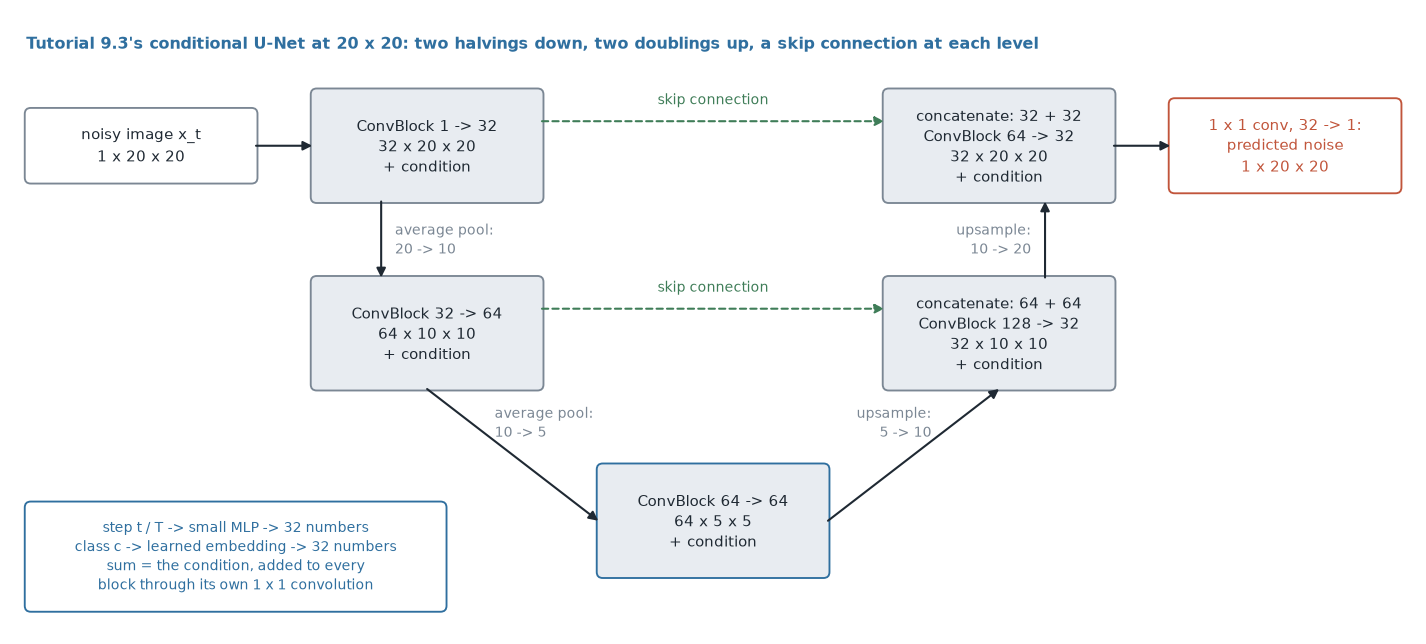

The tutorial's network is a small **U-Net**. The encoder halves the image twice with average
pooling (20 x 20 to 10 x 10 to 5 x 5) and the decoder doubles it back. **Skip connections** hand
each decoder level the encoder's map of the same size, so fine detail does not have to squeeze
through the 5 x 5 bottleneck. The step t (divided by T) and the class label each become a vector
of 32 numbers; the two are added and injected at every level. The two cells below are the
tutorial's `ConvBlock` and `UNet_cond`, unchanged.

| Call | What you give it | What you get back |
|---|---|---|
| `nn.Conv2d(c_in, c_out, 3, padding=1)` | maps (batch, c_in, n, n) | (batch, c_out, n, n): each value a weighted sum over a 3 x 3 patch of every input map |
| `nn.AvgPool2d(2)` | (batch, c, n, n) | (batch, c, n/2, n/2), each value the mean of a 2 x 2 square |
| `nn.Upsample(scale_factor=2, mode='nearest')` | (batch, c, n, n) | (batch, c, 2n, 2n), each value copied into a 2 x 2 square |
| `nn.Embedding(n_classes, ch)` | integer class labels | one learned vector of ch numbers per label |
| `torch.cat([a, b], dim=1)` | two maps of the same size | one map holding the channels of both |

In [13]:
# Supplied by Tutorial 9.3 and reproduced unchanged: two 3 x 3 convolutions with ReLU, the
# building block of every level of the U-Net.
channels = 1 # for MNIST

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

In [14]:
# Supplied by Tutorial 9.3 (its solution) and reproduced unchanged: the conditional U-Net.
# The step t (divided by T) and the class each become 32 numbers, summed into cond_emb and
# added at every level through a 1 x 1 convolution.
class UNet_cond(nn.Module):
    def __init__(self, ch=32, n_classes=10):
        super().__init__()
        # encoder
        self.enc1 = ConvBlock(channels, ch)
        self.enc2 = ConvBlock(ch, ch*2)
        # bottleneck
        self.bot = ConvBlock(ch*2, ch*2)
        # decoder
        self.dec2 = ConvBlock(ch*2 + ch*2, ch)
        self.dec1 = ConvBlock(ch + ch, ch)
        # final
        self.final = nn.Conv2d(ch, channels, 1)

        # timestep embedding
        self.time_mlp = nn.Sequential(
            nn.Linear(1, ch),
            nn.ReLU(),
            nn.Linear(ch, ch)
        )

        # class embedding
        self.class_emb =  nn.Embedding(n_classes,ch)

        # projections to match channel dims
        self.to_e1 = nn.Conv2d(ch, ch, 1)
        self.to_e2 = nn.Conv2d(ch, ch*2, 1)
        self.to_b  = nn.Conv2d(ch, ch*2, 1)
        self.to_d2 = nn.Conv2d(ch, ch, 1)
        self.to_d1 = nn.Conv2d(ch, ch, 1)

        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x, t, y):        
        t = t.float().unsqueeze(-1) / timesteps
        t_emb = self.time_mlp(t).unsqueeze(-1).unsqueeze(-1)  
        
        y_emb = self.class_emb(y).unsqueeze(-1).unsqueeze(-1)
        # print(t_emb.shape)
        # print(y_emb.shape)

        cond_emb = t_emb + y_emb

        e1 = self.enc1(x) + self.to_e1(cond_emb)
        e2 = self.enc2(self.pool(e1)) + self.to_e2(cond_emb)

        b = self.bot(self.pool(e2)) + self.to_b(cond_emb)

        d2 = self.upsample(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2) + self.to_d2(cond_emb)

        d1 = self.upsample(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1) + self.to_d1(cond_emb)

        return self.final(d1)

### 4.1 A shape check at 20 x 20

One forward pass on eight training images at random steps. The output must have the input's
shape, 1 x 20 x 20 per image: one predicted noise value per pixel.

In [15]:
# One forward pass on eight training images at random steps. Two poolings take 20 to 10 to 5
# and the upsamplings bring it back, so the tutorial's U-Net accepts 20 x 20 images unchanged.
check_model = UNet_cond(ch=32, n_classes=n_class).to(device)
x_check = train_dataset.tensors[0][:8].to(device)
y_check = train_dataset.tensors[1][:8].to(device)
t_check = torch.randint(0, timesteps, (8,), device=device)
predicted = check_model(x_check, t_check, y_check)
print(f"input {tuple(x_check.shape)} -> predicted noise {tuple(predicted.shape)}")
print(f"parameters: {sum(p.numel() for p in check_model.parameters()):,}")

input (8, 1, 20, 20) -> predicted noise (8, 1, 20, 20)
parameters: 221,569


## 5 Training

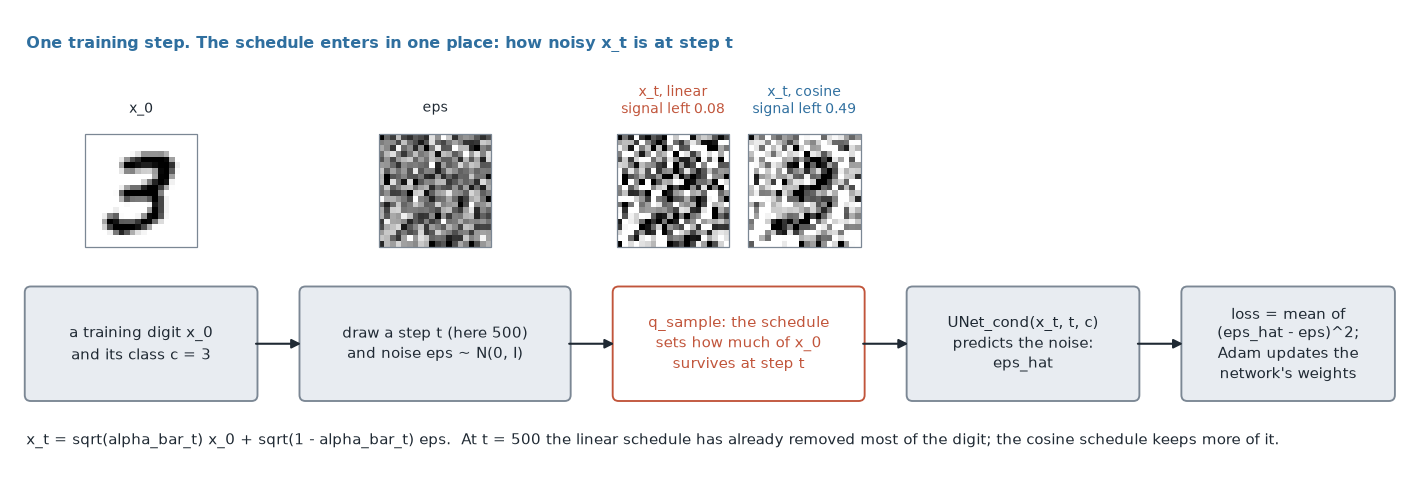

The tutorial's training step: take a batch of clean images, draw a random step t for each, noise
each image to its step with `q_sample`, ask the network for the noise, and score the answer by the
**mean squared error** between the predicted and the true noise. The schedule enters in one place
only, `q_sample`, so one function trains both models.

### 5.1 Settings

The tutorial solution's settings for its conditional model: Adam at a learning rate of 0.0002,
batches of 128 and 150 epochs, with the tutorial's U-Net of 32 channels. `STEP_COUNTS` lists the
sampling budgets section 6 and `main_report.ipynb` compare.

In [16]:
# The tutorial solution's settings for the conditional model, shared by every run so the
# schedule is the only difference between the two models.
epochs = 150
lr = 2e-4
n_channels_unet = 32
SEEDS = (0, 1, 2)
SNAPSHOT_EPOCHS = (10, 25, 50, 100)  # seed 0 also keeps its weights at these epochs
PRINT_EVERY = 10
STEP_COUNTS = (10, 20, 50, 100, 250, 1000)  # the sampling budgets K compared in section 6

In [17]:
# Checkpoints are saved from the CPU, so they load on a machine without a GPU.
def cpu_state(module):
    return {name: tensor.detach().cpu().clone() for name, tensor in module.state_dict().items()}

### 5.2 The training loop

The tutorial's loop, inside a function so it can run once per schedule and seed. Each run first
resets the random seed. A linear run and the cosine run of the same seed therefore start from the
same initial weights and see the same batches, the same steps t and the same noise: **the schedule
is the only difference between them.** Seed 0 also keeps copies of its weights at a few earlier
epochs, which `main_report.ipynb` uses to measure how quickly each schedule's samples improve.

| Call | What you give it | What you get back |
|---|---|---|
| `DataLoader(dataset, batch_size, shuffle, generator)` | a dataset | an iterable of batches; with a seeded generator the shuffled order is the same every run |
| `torch.randint(0, timesteps, (n,), device=device)` | a range and a count | n random whole numbers from 0 to timesteps - 1 |
| `torch.optim.Adam(parameters, lr)` | the network's weights and a learning rate | an optimiser; `.step()` moves every weight a little against its gradient |
| `nn.MSELoss()` | nothing | a loss; called on two tensors it returns their mean squared difference |
| `loss.backward()` | nothing | computes the gradient of `loss` for every weight |

In [18]:
# The tutorial's training loop for UNet_cond, in a function so it runs once per schedule and
# seed. Changes: the schedule is an argument; the shuffle has its own seeded generator; the loss
# is averaged over each epoch on the device (one transfer per epoch, no progress bar);
# and seed 0 keeps copies of its weights at SNAPSHOT_EPOCHS.
def train_cddpm(name, schedule, seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    model = UNet_cond(ch=n_channels_unet, n_classes=n_class).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    train_dataloader = DataLoader(train_dataset, batch_size=bs_train, shuffle=True,
                                  generator=torch.Generator().manual_seed(seed))
    record = {"loss": [], "seconds": [], "snapshots": {}}
    for epoch in range(epochs):
        started = time.time()
        model.train()
        loss_sum = torch.zeros((), device=device)
        for imgs, labels in train_dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            batch_size = imgs.shape[0]
            t = torch.randint(0, timesteps, (batch_size,), device=device).long()
            noise = torch.randn_like(imgs)
            x_t = q_sample(imgs, t, schedule, noise=noise)

            pred_noise = model(x_t,t,labels)
            loss = loss_fn(pred_noise, noise)

            opt.zero_grad()
            loss.backward()
            opt.step()
            loss_sum += loss.detach() * batch_size
        record["loss"].append(loss_sum.item() / len(train_dataset))
        record["seconds"].append(time.time() - started)
        if seed == SEEDS[0] and epoch + 1 in SNAPSHOT_EPOCHS:
            record["snapshots"][epoch + 1] = cpu_state(model)
        if (epoch + 1) % PRINT_EVERY == 0 or epoch == 0:
            print(f"{name} seed {seed} | epoch {epoch + 1:3d}/{epochs} | "
                  f"loss {record['loss'][-1]:.4f} | {record['seconds'][-1]:.1f} s")
    return model, record

### 5.3 Six training runs

Three seeds, and for each seed one model per schedule. One run of a neural network is one draw
from many possible runs, so a difference between the schedules is only convincing if it survives
a change of seed. A line is printed every 10 epochs: the mean loss of that epoch and
how long the epoch took.

In [19]:
# Six runs, seed by seed. A linear run and the cosine run of the same seed start from the same
# initial weights and draw the same batches, steps and noise, because each resets the seed.
# Each model's weights move to the CPU when it finishes, so the GPU holds one model at a time.
weights, records = {}, {}
for seed in SEEDS:
    for name, schedule in schedules.items():
        model, record = train_cddpm(name, schedule, seed)
        weights[name, seed] = cpu_state(model)
        records[name, seed] = record
        del model

linear seed 0 | epoch   1/150 | loss 0.2845 | 7.9 s


linear seed 0 | epoch  10/150 | loss 0.0510 | 7.9 s


linear seed 0 | epoch  20/150 | loss 0.0414 | 7.9 s


linear seed 0 | epoch  30/150 | loss 0.0368 | 7.9 s


linear seed 0 | epoch  40/150 | loss 0.0348 | 7.9 s


...

cosine seed 2 | epoch 110/150 | loss 0.0499 | 7.8 s


cosine seed 2 | epoch 120/150 | loss 0.0501 | 7.8 s


cosine seed 2 | epoch 130/150 | loss 0.0495 | 7.8 s


cosine seed 2 | epoch 140/150 | loss 0.0488 | 7.8 s


cosine seed 2 | epoch 150/150 | loss 0.0493 | 7.8 s


### 5.4 A sanity check

A network that learned nothing could predict zero noise everywhere. Its loss would be the variance
of the noise, 1. Every run must end far below that. The seconds per epoch show what the schedule
does to the cost of training: it changes which noise level each step uses, not how much
computation a step takes.

In [20]:
# Predicting zero noise everywhere scores a loss of 1, the variance of the noise. Every run must
# end far below it; a run that learned nothing would sit near it.
for (name, seed), record in records.items():
    print(f"{name:6s} seed {seed} | final loss {record['loss'][-1]:.4f} | "
          f"{np.mean(record['seconds']):.1f} s per epoch")
    assert record["loss"][-1] < 0.1, f"{name} seed {seed} did not learn"

linear seed 0 | final loss 0.0283 | 7.9 s per epoch
cosine seed 0 | final loss 0.0492 | 7.9 s per epoch
linear seed 1 | final loss 0.0283 | 7.9 s per epoch
cosine seed 1 | final loss 0.0495 | 7.9 s per epoch
linear seed 2 | final loss 0.0287 | 7.9 s per epoch
cosine seed 2 | final loss 0.0493 | 7.9 s per epoch


### 5.5 The loss curves

The loss of every run per epoch, seed 0 drawn solid. The printed change compares the mean loss of
the last 10 epochs with the 10 before: close to 0 means training has levelled off.

**The two schedules' losses cannot be
compared with each other.** Each is the average error over steps t drawn evenly from 1000, and the
two schedules put those steps at different noise levels, so each averages a different mix of easy
and hard questions. `main_report.ipynb` measures the error at each noise level instead
(section 9 there).

linear seed 0 | last 10 epochs 0.0283 | change on the 10 before -0.8%
cosine seed 0 | last 10 epochs 0.0494 | change on the 10 before -0.7%
linear seed 1 | last 10 epochs 0.0283 | change on the 10 before -0.8%
cosine seed 1 | last 10 epochs 0.0494 | change on the 10 before -0.6%
linear seed 2 | last 10 epochs 0.0286 | change on the 10 before -0.9%
cosine seed 2 | last 10 epochs 0.0492 | change on the 10 before -0.5%


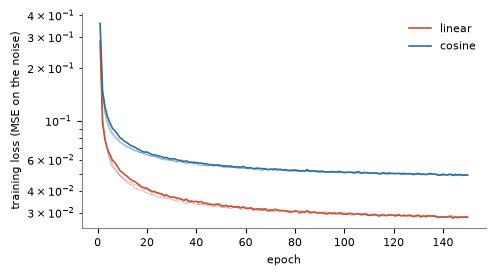

In [21]:
# Every run's loss per epoch, seed 0 solid. The statistic compares the mean loss over the last
# WINDOW epochs with the WINDOW before; a change near 0 means training has levelled off.
WINDOW = min(10, epochs // 2)
fig, ax = plt.subplots(figsize=(5.0, 2.8))
for (name, seed), record in records.items():
    colour = WARM if name == "linear" else ACCENT
    ax.plot(range(1, epochs + 1), record["loss"], color=colour, lw=1.2 if seed == 0 else 0.6,
            alpha=1.0 if seed == 0 else 0.5, label=f"{name}" if seed == 0 else None)
    last = np.mean(record["loss"][-WINDOW:])
    before = np.mean(record["loss"][-2 * WINDOW:-WINDOW])
    print(f"{name:6s} seed {seed} | last {WINDOW} epochs {last:.4f} | change on the "
          f"{WINDOW} before {(last - before) / before:+.1%}")
ax.set(xlabel="epoch", ylabel="training loss (MSE on the noise)", yscale="log")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 5.6 Saving

One file per schedule. Each holds a plain dictionary of weights, one entry per seed and, for seed
0, one per snapshot epoch, saved from the CPU so the file loads on a machine without a GPU. Every
loss, duration and setting goes into `DDPM_history.json`.

In [22]:
# One file per schedule: a dictionary of CPU state_dicts keyed "seed_0", "seed_1", ... and, for
# seed 0, "epoch_10", "epoch_25", ...; the curves, durations and settings go into the JSON file.
for name in schedules:
    checkpoint = {f"seed_{seed}": weights[name, seed] for seed in SEEDS}
    for epoch, state in records[name, SEEDS[0]]["snapshots"].items():
        checkpoint[f"epoch_{epoch}"] = state
    torch.save(checkpoint, f"ddpm_{name}.pth")
history = {"epochs": epochs, "lr": lr, "batch_size": bs_train, "timesteps": timesteps,
           "n_channels_unet": n_channels_unet, "seeds": list(SEEDS),
           "snapshot_epochs": list(SNAPSHOT_EPOCHS), "n_train": len(train_dataset),
           "device": str(device), "torch": torch.__version__,
           "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none",
           "runs": {f"{name}_seed_{seed}": {"loss": r["loss"], "seconds": r["seconds"]}
                    for (name, seed), r in records.items()}}
with open("DDPM_history.json", "w") as handle:
    json.dump(history, handle, indent=1)
print(f"saved {', '.join(f'ddpm_{name}.pth' for name in schedules)} and DDPM_history.json")

saved ddpm_linear.pth, ddpm_cosine.pth and DDPM_history.json


## 6 Sampling

Generation starts from pure noise $x_T$ and applies a reverse step again and again. The tutorial's
sampler visits all 1000 steps. The hypothesis is about doing it in **fewer**, so this section
builds a sampler that visits only K of them, in two versions.

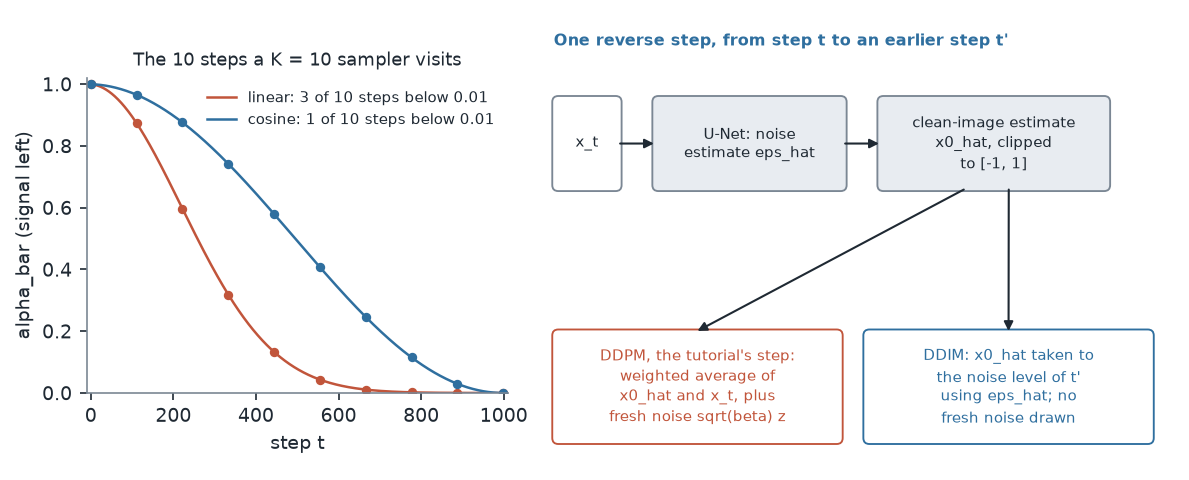

### 6.1 Which steps a K-step sampler visits

K evenly spaced steps from the last to the first, rounded to whole steps: the choice Nichol and
Dhariwal make in their section 4. With K = 1000 it is every step, the tutorial's loop.

| Call | What you give it | What you get back |
|---|---|---|
| `np.linspace(0, 999, K)` | two ends and a count | K evenly spaced values |
| `np.round(v).astype(int)` | real values | the nearest whole numbers |

In [23]:
# Which of the 1000 steps a K-step sampler visits: K evenly spaced values from the first step
# to the last, rounded to whole steps (Nichol and Dhariwal, section 4). K = 1000 visits every
# step, which is the tutorial's loop.
def sampling_steps(n_steps):
    return np.round(np.linspace(0, timesteps - 1, n_steps)).astype(int).tolist()


for n_steps in (10, 20):
    print(f"K = {n_steps} visits steps {sampling_steps(n_steps)}")

K = 10 visits steps [0, 111, 222, 333, 444, 555, 666, 777, 888, 999]
K = 20 visits steps [0, 53, 105, 158, 210, 263, 315, 368, 421, 473, 526, 578, 631, 684, 736, 789, 841, 894, 946, 999]


### 6.2 One reverse step (DDPM)

The tutorial's step, Algorithm 2 of Ho et al. (2020), is

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}}\left(x_t - \frac{\beta_t}{\sqrt{1 - \bar\alpha_t}}\, \hat\epsilon\right) + \sqrt{\beta_t}\, z, \qquad z \sim \mathcal{N}(0, I)$$

where $\hat\epsilon$ is the network's noise estimate. Two changes let it skip steps safely.

**Skipping.** A step from t back to an earlier step t' uses the beta that takes
$\bar\alpha_{t'}$ to $\bar\alpha_t$ in one move, $\beta = 1 - \bar\alpha_t / \bar\alpha_{t'}$,
with $\alpha = 1 - \beta$. When t' = t - 1 this is the tutorial's $\beta_t$.

**The x0 form.** Solving the one-jump formula of section 3 for the clean image gives the
network's current guess of it, $\hat x_0 = (x_t - \sqrt{1 - \bar\alpha_t}\,\hat\epsilon)/\sqrt{\bar\alpha_t}$.
The same step can then be written as a weighted average of that guess and the current image:

$$x_{t'} = \frac{\sqrt{\bar\alpha_{t'}}\,\beta}{1 - \bar\alpha_t}\,\hat x_0 + \frac{\sqrt{\alpha}\,(1 - \bar\alpha_{t'})}{1 - \bar\alpha_t}\, x_t + \sqrt{\beta}\, z$$

The two forms are algebraically the same step (section 6.4 checks it at all 1000 steps). The x0
form has one advantage: $\hat x_0$ is an image, so it can be **clipped** to the data range
[-1, 1] before it is used. Section 6.5 shows why that matters for the cosine schedule.

In [24]:
# The tutorial's reverse step (p_sample_cDDPM), able to jump from step t_index back to any
# earlier step prev_index, with beta recomputed from the two alpha_bars (the tutorial's beta_t
# when prev_index = t_index - 1). It is written in its x0 form: the noise estimate gives a
# clean-image estimate x0_hat, and the step is a weighted average of x0_hat and x_t. Unclipped,
# this is the tutorial's update (checked in DDPM_CosineSchedule.ipynb, section 6.4); clipping
# x0_hat to the data range stops one bad noise estimate from throwing the image off scale
# (DDPM_CosineSchedule.ipynb, section 6.5).
@torch.no_grad()
def p_sample_cDDPM(model, x_t, t_index, y, schedule, prev_index, z, clip=True):
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    alpha_bar = schedule["alpha_bars"][t_index]
    alpha_bar_prev = (schedule["alpha_bars"][prev_index] if prev_index >= 0
                      else alpha_bar.new_ones(()))
    beta = 1 - alpha_bar / alpha_bar_prev
    alpha = 1 - beta
    pred_noise = model(x_t, t, y)
    x0_hat = (x_t - (1 - alpha_bar).sqrt() * pred_noise) / alpha_bar.sqrt()
    if clip:
        x0_hat = x0_hat.clamp(-1, 1)
    mean = (alpha_bar_prev.sqrt() * beta / (1 - alpha_bar) * x0_hat
            + alpha.sqrt() * (1 - alpha_bar_prev) / (1 - alpha_bar) * x_t)
    # the last step adds no noise, as in the tutorial's z = 0 at t_index == 0
    return mean + beta.sqrt() * z if prev_index >= 0 else mean

### 6.3 DDIM

Song et al. (2021) showed that a network trained as in section 5 can also be sampled
**deterministically**. DDIM moves $\hat x_0$ to the earlier step's noise level and reuses the
current noise estimate as that level's noise, drawing no fresh noise:

$$x_{t'} = \sqrt{\bar\alpha_{t'}}\,\hat x_0 + \sqrt{1 - \bar\alpha_{t'}}\,\hat\epsilon$$

It was designed for sampling in few steps, which makes it the second sampler of the comparison.
It uses the same clipped $\hat x_0$, with $\hat\epsilon$ recomputed from it so the two agree.

In [25]:
# DDIM (Song et al., 2021): the same network and the same x0_hat, but a deterministic step that
# moves x0_hat to the earlier step's noise level and reuses the noise estimate instead of
# drawing fresh noise. The estimate is recomputed from the clipped x0_hat so the two agree.
@torch.no_grad()
def ddim_step(model, x_t, t_index, y, schedule, prev_index, clip=True):
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    alpha_bar = schedule["alpha_bars"][t_index]
    alpha_bar_prev = (schedule["alpha_bars"][prev_index] if prev_index >= 0
                      else alpha_bar.new_ones(()))
    pred_noise = model(x_t, t, y)
    x0_hat = (x_t - (1 - alpha_bar).sqrt() * pred_noise) / alpha_bar.sqrt()
    if clip:
        x0_hat = x0_hat.clamp(-1, 1)
        pred_noise = (x_t - alpha_bar.sqrt() * x0_hat) / (1 - alpha_bar).sqrt()
    return alpha_bar_prev.sqrt() * x0_hat + (1 - alpha_bar_prev).sqrt() * pred_noise

### 6.4 The sampling loop, and a check against the tutorial

The tutorial's loop over the step list of section 6.1. All the randomness, the starting noise and
every z, comes from one seeded generator on the CPU and is then moved to the device. A seed
therefore gives the same samples on any machine, and the two schedules start from the same noise,
so their samples can be compared image by image. `generate` draws large sets in chunks of 1,000.

The check after it runs the x0 form, unclipped, against the tutorial's own update at every one of
the 1000 steps, in double precision, with a stand-in network that always returns the same noise
estimate, so only the formulas are compared.

| Call | What you give it | What you get back |
|---|---|---|
| `torch.Generator().manual_seed(s)` | a seed | a private random-number source on the CPU |
| `torch.randn(shape, generator=g)` | a shape and a generator | standard normal values drawn from that source |
| `x.clamp(-1, 1)` | a tensor | the tensor with every value limited to [-1, 1] |

In [26]:
# The tutorial's sampling loop over the steps sampling_steps lists: start from pure noise and step
# down to 0. Every random draw comes from one seeded CPU generator and is then moved to the
# device, so a seed gives the same samples on any machine and both schedules start alike.
@torch.no_grad()
def p_sample_loop_cDDPM(model, y, schedule, n_steps=timesteps, sampler="ddpm", seed=1337,
                        clip=True):
    model.eval()
    generator = torch.Generator().manual_seed(seed)
    x = torch.randn(y.shape[0], channels, image_size, image_size, generator=generator).to(device)
    steps = sampling_steps(n_steps)
    for i in reversed(range(len(steps))):
        prev_index = steps[i - 1] if i > 0 else -1
        if sampler == "ddim":
            x = ddim_step(model, x, steps[i], y, schedule, prev_index, clip)
        else:
            z = torch.randn(x.shape, generator=generator).to(device)
            x = p_sample_cDDPM(model, x, steps[i], y, schedule, prev_index, z, clip)
    return x.clamp(-1,1)


# Large sets are drawn in chunks, chunk k with seed + k, and returned in [0, 1] on the CPU.
def generate(model, labels, schedule, n_steps, sampler, seed=1337, batch_size=1000):
    parts = []
    for number, start in enumerate(range(0, len(labels), batch_size)):
        y = labels[start:start + batch_size].to(device)
        x = p_sample_loop_cDDPM(model, y, schedule, n_steps, sampler, seed + number)
        parts.append(((x + 1) / 2).cpu())
    return torch.cat(parts)

In [27]:
# Section 6.2's claim, checked: unclipped and with no step skipped, the x0 form equals the
# tutorial's update at every step. Double precision, and a stand-in network that returns one
# fixed noise estimate, so only the two formulas are compared.
def tutorial_update(schedule, x_t, t_index, pred_noise, z):
    t = torch.full((x_t.shape[0],), t_index, device=x_t.device, dtype=torch.long)
    beta = extract(schedule["betas"], t, x_t.shape)
    alpha = extract(schedule["alphas"], t, x_t.shape)
    alpha_bar = extract(schedule["alpha_bars"], t, x_t.shape)
    sigma = torch.sqrt(beta)
    z = 0 if t_index == 0 else z
    return 1.0 / alpha.sqrt() * (x_t - beta / ( (1 - alpha_bar).sqrt() ) * pred_noise) + sigma*z


check_generator = torch.Generator().manual_seed(SEED)
shape = (16, channels, image_size, image_size)
x_t, estimate, z = (torch.randn(shape, generator=check_generator, dtype=torch.float64).to(device)
                    for _ in range(3))
y_unused = torch.zeros(16, dtype=torch.long, device=device)
for name, build in SCHEDULE_FUNCTIONS.items():
    schedule64 = make_schedule(build(timesteps).double())
    worst = max((p_sample_cDDPM(lambda x, t, y: estimate, x_t, s, y_unused, schedule64, s - 1, z,
                                clip=False) - tutorial_update(schedule64, x_t, s, estimate, z))
                .abs().max().item() for s in range(timesteps))
    print(f"{name:6s} | largest difference from the tutorial's update over all "
          f"{timesteps} steps: {worst:.1e}")
    assert worst < 1e-6, "the x0 form must reproduce the tutorial's step"

linear | largest difference from the tutorial's update over all 1000 steps: 6.4e-13


cosine | largest difference from the tutorial's update over all 1000 steps: 2.3e-12


### 6.5 Why the clip

In the tutorial's form the noise estimate, and any error in it, is multiplied by
$\beta / (\sqrt{\alpha}\sqrt{1 - \bar\alpha_t})$. The table prints that multiplier for the first
reverse step, where the network sees pure noise, for each number of steps K. The cosine schedule's
last beta is 0.999, so its $\alpha$ there is 0.001 and the multiplier is large even when no step is
skipped; skipping steps makes it larger still. In the x0 form the same error lands in
$\hat x_0$, the clip bounds it by the data range, and the step keeps only a fraction of
$\hat x_0$.

In [28]:
# How much an error in the noise estimate is multiplied on the first reverse step, where the
# network sees pure noise, in the tutorial's form: beta / (sqrt(alpha) * sqrt(1 - alpha_bar)).
print("first reverse step: multiplier on an error in the noise estimate, by number of steps K")
for name, schedule in schedules.items():
    cells = []
    for n_steps in STEP_COUNTS:
        first, second = sampling_steps(n_steps)[-1], sampling_steps(n_steps)[-2]
        alpha_bar = schedule["alpha_bars"][first].double()
        alpha = alpha_bar / schedule["alpha_bars"][second].double()
        gain = (1 - alpha) / (alpha.sqrt() * (1 - alpha_bar).sqrt())
        cells.append(f"K={n_steps} {gain:,.2f}")
    print(f"{name:6s} | " + " | ".join(cells))

first reverse step: multiplier on an error in the noise estimate, by number of steps K
linear | K=10 2.54 | K=20 1.09 | K=50 0.40 | K=100 0.20 | K=250 0.08 | K=1000 0.02
cosine | K=10 3,492.67 | K=20 1,674.11 | K=50 632.36 | K=100 316.21 | K=250 126.48 | K=1000 31.59


## 7 Generated digits

The tutorial's last step, in the brief's layout: 12 samples per digit with the digits as rows,
120 images per model, from each schedule's seed-0 model with the full 1000-step sampler and the
same starting noise. This is a first look; `main_report.ipynb` makes the comparison.

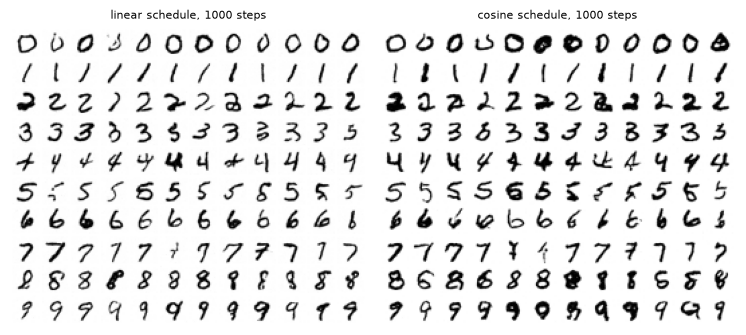

In [29]:
# The tutorial's last step in the brief's layout: 12 samples per digit, digits as rows, from
# each schedule's seed-0 model with the full 1000-step sampler and the same starting noise.
sample_per_class = 12
labels = torch.arange(0,10).unsqueeze(1).repeat(1,sample_per_class).view(-1).to(device)
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
for ax, name in zip(axes, schedules):
    model = UNet_cond(ch=n_channels_unet, n_classes=n_class).to(device)
    _ = model.load_state_dict(weights[name, SEEDS[0]])
    samples = (p_sample_loop_cDDPM(model, labels, schedules[name]) + 1.0) / 2.0
    ax.imshow(utils.make_grid(samples, nrow=12, pad_value=1)[0].cpu(), cmap="gray",
              vmin=0, vmax=1)
    ax.set_title(f"{name} schedule, {timesteps} steps")
    ax.axis("off")
plt.tight_layout()
plt.show()

### 7.1 Real digits

Twelve training images of each digit, for comparison.

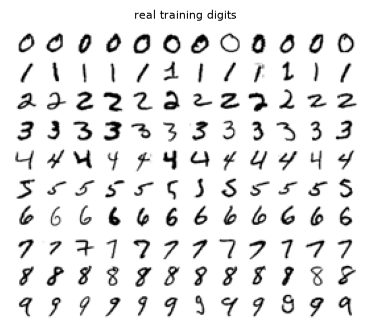

In [30]:
# Twelve training images of each digit, in the same layout, for comparison.
first = torch.cat([torch.nonzero(train_labels == digit)[:12, 0] for digit in range(10)])
fig, ax = plt.subplots(figsize=(3.75, 3.6))
ax.imshow(utils.make_grid(train_images[first], nrow=12, pad_value=1)[0], cmap="gray",
          vmin=0, vmax=1)
ax.set_title("real training digits")
ax.axis("off")
plt.tight_layout()
plt.show()